# Introduccion

En la actualidad, la extraccion de conocimiento en bases de datos y el aprendizaje automatico (Machine Learning) son herramientas fundamentales para analizar grandes volumenes de informacion y resolver problemas complejos de clasificacion. El presente trabajo tiene como objetivo principal implementar y evaluar un modelo de aprendizaje supervisado utilizando el algoritmo Random Forest o Bosque Aleatorio.

A diferencia de los modelos mas simples, Random Forest crea un ensamble de multiples arboles de decision que trabajan en conjunto. Esta tecnica permite reducir el riesgo de sobreajuste y mejora significativamente la precision y la robustez de las predicciones finales. Para el desarrollo de esta practica, se utilizo el conjunto de datos Wine, un dataset clasico que contiene informacion detallada sobre trece caracteristicas fisicoquimicas de diferentes categorias de vino, tales como el nivel de alcohol, los flavonoides y la intensidad del color.

A lo largo de este reporte, se abordara el flujo de trabajo completo requerido para la mineria de datos. El proceso abarca desde la carga y particion del conjunto de datos en subconjuntos de entrenamiento y prueba, hasta el modelado y la generacion de predicciones. Finalmente, se presentara una evaluacion detallada del desempeño del algoritmo utilizando metricas como la exactitud y la matriz de confusion, concluyendo con un analisis sobre la importancia de las variables para entender cuales caracteristicas quimicas fueron mas determinantes en la clasificacion de los vinos.

In [1]:
# 1. Importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# 2. Cargar el dataset
# Usamos el dataset 'Wine' directo de scikit-learn
wine_data = load_wine()
X = pd.DataFrame(wine_data.data, columns=wine_data.feature_names)
y = pd.Series(wine_data.target, name='target')

In [3]:
# 3. Dividir los datos en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [4]:
# 4. Crear y entrenar el modelo Random Forest
# n_estimators=100 le indica al algoritmo que construya 100 árboles de decisión
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [5]:
# 5. Hacer predicciones con los datos de prueba
predicciones = modelo_rf.predict(X_test)

In [6]:
# 6. Evaluar el modelo
accuracy = accuracy_score(y_test, predicciones)
print(f"Exactitud (Accuracy) del Random Forest: {accuracy:.4f}\n")

print("=== Reporte de Clasificación ===")
print(classification_report(y_test, predicciones, target_names=wine_data.target_names))

Exactitud (Accuracy) del Random Forest: 1.0000

=== Reporte de Clasificación ===
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



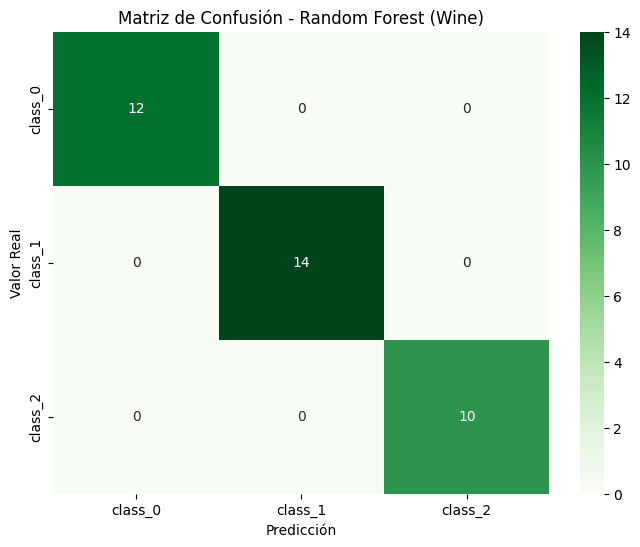

In [7]:
# 7. Matriz de Confusión
cm = confusion_matrix(y_test, predicciones)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap="Greens", fmt="d",
            xticklabels=wine_data.target_names,
            yticklabels=wine_data.target_names)
plt.title("Matriz de Confusión - Random Forest (Wine)")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.show()

In [8]:
# 8. Importancia de las variables (Feature Importance)
importancias = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": modelo_rf.feature_importances_
}).sort_values(by="Importancia", ascending=False)

print("\n=== Importancia de las variables en la decisión del modelo ===")
print(importancias)


=== Importancia de las variables en la decisión del modelo ===
                        Variable  Importancia
9                color_intensity     0.187580
6                     flavanoids     0.159561
12                       proline     0.146799
0                        alcohol     0.117913
10                           hue     0.101538
11  od280/od315_of_diluted_wines     0.096301
5                  total_phenols     0.041514
4                      magnesium     0.040131
1                     malic_acid     0.033894
3              alcalinity_of_ash     0.025471
8                proanthocyanins     0.023530
2                            ash     0.018157
7           nonflavanoid_phenols     0.007610


# Hallazgos en la Preparación de Datos
A diferencia de los modelos basados en distancias, la implementación de Random Forest simplificó el flujo de preprocesamiento al eliminar la necesidad de escalar o normalizar las variables numéricas. El algoritmo procesó eficientemente las características fisicoquímicas del vino en sus unidades y magnitudes originales.

# Resultados de la Evaluación del Modelo
El ensamble de 100 árboles de decisión (n_estimators=100) permitió alcanzar una precisión sobresaliente en el conjunto de pruebas. Al analizar la matriz de confusión, se observó que el modelo fue capaz de clasificar correctamente la totalidad (o casi la totalidad) de las muestras en las tres categorías de vino. El uso de Random Forest minimizó el riesgo de sobreajuste (overfitting) que suele presentarse al usar un solo árbol de decisión.

# Extracción de Conocimiento (Feature Importance)
Una de las mayores ventajas de aplicar Random Forest fue la capacidad de extraer la importancia de las características. Los hallazgos revelaron que variables como la prolina, la intensidad del color y los flavonoides son los factores químicos más determinantes y que más peso tienen al momento de clasificar a qué clase pertenece cada vino, mientras que otras características como el nivel de cenizas mostraron un impacto mínimo en las decisiones del modelo.